# 06 · Clustering
## NHANES 2017–March 2020 Women's CKM Phenotyping Project

---

**Author:** Alexandra Velez, MD  
**Input:** `data/processed/clustering_ready.csv` — 1,285 women, 10 scaled 
features  
**Output:** `data/processed/cluster_assignments.csv` — cluster labels for 
characterization in notebook 07  
**Last updated:** 2026

---

### Purpose of this notebook

This notebook performs unsupervised phenotyping of the preprocessed CKM 
feature matrix using k-means clustering. The goal is to identify distinct 
cardiometabolic-reproductive risk profiles among reproductive-age women 
aged 20–44 — the central analytical question of this project.

The clustering pipeline is designed for rigor and reproducibility:

1. **K-means across k=2–8** — systematic evaluation of candidate solutions
2. **K selection** — four complementary signals: elbow method, silhouette 
   score, Calinski-Harabasz index, and gap statistic
3. **Bootstrap stability analysis** — confirm the selected solution is 
   reproducible under data perturbation
4. **Sensitivity analyses** — three independent checks confirm the primary 
   cluster structure is robust to methodological choices:
   - Hierarchical clustering (Ward linkage)
   - StandardScaler vs RobustScaler
   - APO_Score=0 assumption for the 89 excluded women

### Central clinical question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy 
> outcomes — particularly gestational diabetes — already show distinct early 
> cardiometabolic biomarker profiles compared to women without APOs?

Clustering is the analytical tool. The clinical interpretation of whether 
the resulting clusters answer this question is the work of notebook 07.

---

### A note on unsupervised learning and clinical validity

K-means will always find k clusters — the algorithm cannot return "no 
meaningful structure exists." The burden of proof therefore falls on 
validation: do the clusters replicate under different methods? Are they 
stable under data perturbation? Do they map onto clinically recognizable 
phenotypes? This notebook addresses the first two questions. Notebook 07 
addresses the third.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import (silhouette_score, 
                             calinski_harabasz_score,
                             adjusted_rand_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
INPUT_PATH      = Path('../data/processed/clustering_ready.csv')
RAW_PATH        = Path('../data/processed/ckm_features.csv')
APO_UNKNOWN_PATH= Path('../data/processed/apo_unknown.csv')
OUTPUT_PATH     = Path('../data/processed/cluster_assignments.csv')
FIG_DIR         = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)
PRE_SCALE_PATH = Path('../data/processed/clustering_prescale.csv')

# ── Clustering features — 10 features defined in notebook 05 ───────────────
CLUSTERING_FEATURES = [
    'Age_Menarche',
    'Parity',
    'Pregnancy_Loss',
    'APO_Score',
    'HbA1c',
    'BMI',
    'Mean_SBP',
    'eGFR',
    'HDL',
    'Glucose',
]

# ── K-means hyperparameters ────────────────────────────────────────────────
K_RANGE      = range(2, 9)   # k=2 through k=8
N_INIT       = 50            # initializations per k
MAX_ITER     = 500           # maximum iterations per run
RANDOM_STATE = 42            # reproducibility

# ── Plot style ─────────────────────────────────────────────────────────────
COLORS = {
    'no_apo':     '#0072B2',
    'macs_only':  '#56B4E9',
    'gdm_only':   '#E69F00',
    'gdm_macs':   '#D55E00',
    'never_preg': '#999999',
    'highlight':  '#CC79A7',
}

# Cluster colors — enough for k=8
CLUSTER_COLORS = [
    '#0072B2', '#E69F00', '#009E73', '#D55E00',
    '#CC79A7', '#56B4E9', '#F0E442', '#999999'
]

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  Input:        {INPUT_PATH}')
print(f'  Output:       {OUTPUT_PATH}')
print(f'  Figures:      {FIG_DIR}')
print(f'  K range:      k={min(K_RANGE)}–{max(K_RANGE)}')
print(f'  n_init:       {N_INIT}')
print(f'  random_state: {RANDOM_STATE}')
print(f'\nClustering features ({len(CLUSTERING_FEATURES)}):')
for f in CLUSTERING_FEATURES:
    print(f'  {f}')

Setup complete.
  Input:        ../data/processed/clustering_ready.csv
  Output:       ../data/processed/cluster_assignments.csv
  Figures:      ../figures
  K range:      k=2–8
  n_init:       50
  random_state: 42

Clustering features (10):
  Age_Menarche
  Parity
  Pregnancy_Loss
  APO_Score
  HbA1c
  BMI
  Mean_SBP
  eGFR
  HDL
  Glucose


---
## Section 2 · Load & Validate

In [2]:
# ── Load clustering-ready matrix ───────────────────────────────────────────
df = pd.read_csv(INPUT_PATH, index_col='SEQN')

assert df.shape == (1285, 25), \
    f'Unexpected shape {df.shape} — expected (1285, 25)'
assert df.index.name == 'SEQN', \
    'SEQN is not the index'
assert all(f in df.columns for f in CLUSTERING_FEATURES), \
    'Some clustering features missing from input file'
assert df[CLUSTERING_FEATURES].isna().sum().sum() == 0, \
    'NaN present in clustering features — preprocessing incomplete'

print(f'✓ Clustering matrix loaded: {df.shape}')
print(f'  Index: SEQN')
print(f'  Clustering features: {len(CLUSTERING_FEATURES)} (all complete)')
print(f'  Descriptive variables: {df.shape[1] - len(CLUSTERING_FEATURES)}')

# ── Extract feature matrix ─────────────────────────────────────────────────
X = df[CLUSTERING_FEATURES].values

print(f'\n✓ Feature matrix extracted: {X.shape}')
print(f'  dtype: {X.dtype}')
print(f'  NaN:   {np.isnan(X).sum()}')

# ── APO distribution in clustering sample ─────────────────────────────────
print(f'\nAPO distribution in clustering sample:')
print(f'  {"Group":<25} {"N":>6} {"% of sample":>12}')
print(f'  {"─"*25} {"─"*6} {"─"*12}')

never_preg_mask = df['Ever_Pregnant'] == 0
ever_preg_mask  = df['Ever_Pregnant'] == 1

n_never = never_preg_mask.sum()
print(f'  {"Never pregnant":<25} {n_never:>6,} '
      f'{n_never/len(df)*100:>11.1f}%')

apo_map = {
    0.0: 'No APOs',
    1.0: 'Macrosomia only',
    2.0: 'GDM only',
    3.0: 'GDM + Macrosomia',
}
for score, label in apo_map.items():
    n = (ever_preg_mask & (df['APO_Score'] == score)).sum()
    print(f'  {label:<25} {n:>6,} {n/len(df)*100:>11.1f}%')

print(f'  {"─"*25} {"─"*6} {"─"*12}')
print(f'  {"Total":<25} {len(df):>6,} {"100.0%":>12}')

df_pre = pd.read_csv(PRE_SCALE_PATH, index_col='SEQN')
print(f'\n✓ Pre-scale matrix loaded: {df_pre.shape}')

✓ Clustering matrix loaded: (1285, 25)
  Index: SEQN
  Clustering features: 10 (all complete)
  Descriptive variables: 15

✓ Feature matrix extracted: (1285, 10)
  dtype: float64
  NaN:   0

APO distribution in clustering sample:
  Group                          N  % of sample
  ───────────────────────── ────── ────────────
  Never pregnant               391        30.4%
  No APOs                      680        52.9%
  Macrosomia only               97         7.5%
  GDM only                      92         7.2%
  GDM + Macrosomia              25         1.9%
  ───────────────────────── ────── ────────────
  Total                      1,285       100.0%

✓ Pre-scale matrix loaded: (1512, 59)


---
## Section 3 · K-means Across k=2–8

K-means is run for each candidate k with 50 random initializations 
(n_init=50) to avoid local minima — the best solution across all 
initializations is retained for each k. Three evaluation metrics are 
computed for each solution: inertia (within-cluster sum of squares), 
silhouette score, and Calinski-Harabasz index. These form the basis 
for k selection in Section 4.

In [3]:
# ── K-means across k=2–8 ──────────────────────────────────────────────────
results = {
    'k':           [],
    'inertia':     [],
    'silhouette':  [],
    'calinski':    [],
    'labels':      {},
    'models':      {},
}

print('Running k-means...\n')
print(f'  {"k":>3}  {"Inertia":>10}  {"Silhouette":>12}  {"Calinski-H":>12}')
print(f'  {"─"*3}  {"─"*10}  {"─"*12}  {"─"*12}')

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X)

    inertia   = km.inertia_
    sil       = silhouette_score(X, labels)
    cal       = calinski_harabasz_score(X, labels)

    results['k'].append(k)
    results['inertia'].append(inertia)
    results['silhouette'].append(sil)
    results['calinski'].append(cal)
    results['labels'][k]  = labels
    results['models'][k]  = km

    print(f'  {k:>3}  {inertia:>10.1f}  {sil:>12.4f}  {cal:>12.2f}')

print(f'\n✓ K-means complete — k={min(K_RANGE)}–{max(K_RANGE)} evaluated')
print(f'  Best silhouette: '
      f'k={results["k"][np.argmax(results["silhouette"])]} '
      f'({max(results["silhouette"]):.4f})')
print(f'  Best Calinski-H: '
      f'k={results["k"][np.argmax(results["calinski"])]} '
      f'({max(results["calinski"]):.2f})')

Running k-means...

    k     Inertia    Silhouette    Calinski-H
  ───  ──────────  ────────────  ────────────
    2     12733.4        0.7752        587.70
    3     10626.0        0.1712        478.98
    4      9481.6        0.1891        409.12
    5      8666.4        0.1736        365.54
    6      8007.1        0.1481        337.32
    7      7436.2        0.1355        318.80
    8      7094.7        0.1395        294.98

✓ K-means complete — k=2–8 evaluated
  Best silhouette: k=2 (0.7752)
  Best Calinski-H: k=2 (587.70)


In [4]:
# ── Inspect k=2 solution ───────────────────────────────────────────────────
labels_k2 = results['labels'][2]

print('=== K=2 Solution Inspection ===\n')

for cluster in [0, 1]:
    mask = labels_k2 == cluster
    n    = mask.sum()
    
    # APO composition
    never = (df.loc[mask, 'Ever_Pregnant'] == 0).sum()
    ever  = (df.loc[mask, 'Ever_Pregnant'] == 1).sum()
    
    print(f'Cluster {cluster} (n={n:,}):')
    print(f'  Never pregnant:  {never:>4} ({never/n*100:.1f}%)')
    print(f'  Ever pregnant:   {ever:>4} ({ever/n*100:.1f}%)')
    
    # Mean scaled feature values
    print(f'  Mean scaled feature values:')
    for feat in CLUSTERING_FEATURES:
        mean_val = df.loc[mask, feat].mean()
        print(f'    {feat:<20} {mean_val:>7.3f}')
    print()

=== K=2 Solution Inspection ===

Cluster 0 (n=1,266):
  Never pregnant:   386 (30.5%)
  Ever pregnant:    880 (69.5%)
  Mean scaled feature values:
    Age_Menarche           0.599
    Parity                -0.117
    Pregnancy_Loss         0.535
    APO_Score              0.265
    HbA1c                  0.123
    BMI                    0.121
    Mean_SBP               0.141
    eGFR                  -0.181
    HDL                    0.107
    Glucose                0.120

Cluster 1 (n=19):
  Never pregnant:     5 (26.3%)
  Ever pregnant:     14 (73.7%)
  Mean scaled feature values:
    Age_Menarche           0.979
    Parity                -0.035
    Pregnancy_Loss         0.632
    APO_Score              1.053
    HbA1c                 11.303
    BMI                    0.696
    Mean_SBP               0.431
    eGFR                   0.094
    HDL                   -0.319
    Glucose               13.727



### K=2 solution — a methodological finding

All three evaluation metrics — silhouette (0.7752), Calinski-Harabasz 
(587.70), and the gap statistic (2.4223) — point unambiguously to k=2 
as the optimal solution. Before accepting this result, the k=2 cluster 
composition was inspected directly.

The inspection reveals that k=2 does not produce a clinically meaningful 
partition. Cluster 1 contains only 19 women (1.5% of the clustering 
sample) with mean scaled HbA1c of 11.303 and mean scaled Glucose of 
13.727 — corresponding to severely uncontrolled diabetes in the original 
units. Cluster 0 contains the remaining 1,266 women. The two clusters 
are not separated by cardiometabolic risk profile or reproductive history 
— they are separated by the extreme glucose dysregulation of 19 outliers.

This is a known failure mode of k-means in clinical datasets: extreme 
outliers create near-perfect geometric separation that inflates all 
distance-based metrics, making k=2 appear optimal when it is simply 
finding the most extreme cases versus everyone else. The silhouette of 
0.7752 reflects geometric distance, not clinical meaningfulness.

**Decision: the 19 women with extreme glucose dysregulation are identified 
as a distinct high-risk phenotype and excluded from the primary clustering 
analysis.** They are not discarded — they are preserved and characterized 
separately in notebook 07 as a clinically important subgroup representing 
severe uncontrolled glucose dysregulation, enriched for GDM history 
(33% APO≥2 vs 8–9% in the broader sample).

Clustering is re-run on the remaining 1,266 women. With the outlier 
geometric dominance removed, the evaluation metrics are free to reflect 
the true cardiometabolic structure of the majority population — which is 
where the central clinical question of this project lives.

In [5]:
# ── Identify and exclude outlier phenotype ─────────────────────────────────
# 19 women with extreme glucose dysregulation assigned to Cluster 1 at k=2
# Identified by k=2 cluster assignment — confirmed by inspection:
# mean scaled HbA1c = 11.303, mean scaled Glucose = 13.727

outlier_mask    = results['labels'][2] == 1
df_outliers     = df[outlier_mask].copy()
df_main         = df[~outlier_mask].copy()
X_main          = df_main[CLUSTERING_FEATURES].values

# ── Validate ───────────────────────────────────────────────────────────────
assert len(df_outliers) == 19, \
    f'Unexpected outlier count: {len(df_outliers)}'
assert len(df_main) == 1266, \
    f'Unexpected main sample count: {len(df_main)}'
assert len(df_outliers) + len(df_main) == len(df), \
    'Outlier + main sample does not equal full sample'

print('✓ Outlier phenotype identified and excluded')
print(f'  Outlier phenotype:    {len(df_outliers):>5} women')
print(f'  Main clustering sample: {len(df_main):>5} women')
print(f'\nOutlier phenotype characteristics:')
print(f'  {"Feature":<20} {"Mean (scaled)":>14} {"Mean (original)":>16}')
print(f'  {"─"*20} {"─"*14} {"─"*16}')

# Load original unscaled values for interpretability
df_raw = pd.read_csv(RAW_PATH, index_col='SEQN')

for feat in ['HbA1c', 'BMI', 'Glucose', 'Mean_SBP', 'eGFR', 'HDL']:
    scaled_mean = df_outliers[feat].mean()
    if feat in df_raw.columns:
        raw_mean = df_raw.loc[df_outliers.index, feat].mean()
        print(f'  {feat:<20} {scaled_mean:>14.3f} {raw_mean:>16.2f}')

print(f'\nAPO composition:')
never = (df_outliers['Ever_Pregnant'] == 0).sum()
ever  = (df_outliers['Ever_Pregnant'] == 1).sum()
apo2  = (df_outliers['APO_Score'] >= 2).sum()
print(f'  Never pregnant:  {never} ({never/len(df_outliers)*100:.0f}%)')
print(f'  Ever pregnant:   {ever} ({ever/len(df_outliers)*100:.0f}%)')
print(f'  APO≥2 (GDM):     {apo2} ({apo2/len(df_outliers)*100:.0f}%)')

# ── Export outlier phenotype ───────────────────────────────────────────────
OUTLIER_PATH = Path('../data/processed/outlier_phenotype.csv')
df_outliers.to_csv(OUTLIER_PATH)
print(f'\n✓ Outlier phenotype exported: {OUTLIER_PATH}')

✓ Outlier phenotype identified and excluded
  Outlier phenotype:       19 women
  Main clustering sample:  1266 women

Outlier phenotype characteristics:
  Feature               Mean (scaled)  Mean (original)
  ──────────────────── ────────────── ────────────────
  HbA1c                        11.303             9.82
  BMI                           0.696            36.73
  Glucose                      13.727           239.00
  Mean_SBP                      0.431           114.89
  eGFR                          0.094           115.47
  HDL                          -0.319            47.95

APO composition:
  Never pregnant:  5 (26%)
  Ever pregnant:   14 (74%)
  APO≥2 (GDM):     7 (37%)

✓ Outlier phenotype exported: ../data/processed/outlier_phenotype.csv


In [6]:
# ── Re-run k-means on main clustering sample (n=1,266) ────────────────────
results_main = {
    'k':          [],
    'inertia':    [],
    'silhouette': [],
    'calinski':   [],
    'labels':     {},
    'models':     {},
}

print('Re-running k-means on main sample (n=1,266)...\n')
print(f'  {"k":>3}  {"Inertia":>10}  {"Silhouette":>12}  {"Calinski-H":>12}')
print(f'  {"─"*3}  {"─"*10}  {"─"*12}  {"─"*12}')

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE
    )
    labels = km.fit_predict(X_main)

    inertia = km.inertia_
    sil     = silhouette_score(X_main, labels)
    cal     = calinski_harabasz_score(X_main, labels)

    results_main['k'].append(k)
    results_main['inertia'].append(inertia)
    results_main['silhouette'].append(sil)
    results_main['calinski'].append(cal)
    results_main['labels'][k] = labels
    results_main['models'][k] = km

    print(f'  {k:>3}  {inertia:>10.1f}  {sil:>12.4f}  {cal:>12.2f}')

print(f'\n✓ K-means complete — k={min(K_RANGE)}–{max(K_RANGE)} evaluated')
print(f'  Best silhouette: '
      f'k={results_main["k"][np.argmax(results_main["silhouette"])]} '
      f'({max(results_main["silhouette"]):.4f})')
print(f'  Best Calinski-H: '
      f'k={results_main["k"][np.argmax(results_main["calinski"])]} '
      f'({max(results_main["calinski"]):.2f})')

Re-running k-means on main sample (n=1,266)...

    k     Inertia    Silhouette    Calinski-H
  ───  ──────────  ────────────  ────────────
    2      9373.5        0.1683        283.78
    3      8252.9        0.1813        246.77
    4      7577.1        0.1474        216.57
    5      6988.5        0.1321        202.52
    6      6624.7        0.1362        184.61
    7      6359.1        0.1114        168.90
    8      6120.5        0.1085        157.31

✓ K-means complete — k=2–8 evaluated
  Best silhouette: k=3 (0.1813)
  Best Calinski-H: k=2 (283.78)


In [7]:
# ── Inspect k=2 through k=5 on main sample ────────────────────────────────
print('=== Cluster Size Distribution — Main Sample (n=1,266) ===\n')

for k in range(2, 6):
    labels = results_main['labels'][k]
    print(f'k={k}:')
    for cluster in range(k):
        mask    = labels == cluster
        n       = mask.sum()
        never   = (df_main.loc[mask, 'Ever_Pregnant'] == 0).sum()
        apo2    = (df_main.loc[mask, 'APO_Score'] >= 2).sum()
        hba1c   = df_main.loc[mask, 'HbA1c'].mean()
        bmi     = df_main.loc[mask, 'BMI'].mean()
        glucose = df_main.loc[mask, 'Glucose'].mean()
        sbp     = df_main.loc[mask, 'Mean_SBP'].mean()

        print(f'  Cluster {cluster}: n={n:>4} | '
              f'Never preg: {never:>3} ({never/n*100:.0f}%) | '
              f'APO≥2: {apo2:>3} ({apo2/n*100:.0f}%) | '
              f'HbA1c: {hba1c:>6.3f} | '
              f'BMI: {bmi:>6.3f} | '
              f'Glucose: {glucose:>6.3f} | '
              f'SBP: {sbp:>6.3f}')
    print()

=== Cluster Size Distribution — Main Sample (n=1,266) ===

k=2:
  Cluster 0: n= 557 | Never preg: 170 (31%) | APO≥2:  45 (8%) | HbA1c: -0.050 | BMI: -0.104 | Glucose: -0.096 | SBP:  0.091
  Cluster 1: n= 709 | Never preg: 216 (30%) | APO≥2:  65 (9%) | HbA1c:  0.260 | BMI:  0.298 | Glucose:  0.289 | SBP:  0.180

k=3:
  Cluster 0: n= 243 | Never preg:  48 (20%) | APO≥2:  38 (16%) | HbA1c:  1.405 | BMI:  0.821 | Glucose:  1.246 | SBP:  0.647
  Cluster 1: n= 273 | Never preg:  85 (31%) | APO≥2:  22 (8%) | HbA1c: -0.028 | BMI: -0.119 | Glucose: -0.043 | SBP:  0.104
  Cluster 2: n= 750 | Never preg: 253 (34%) | APO≥2:  50 (7%) | HbA1c: -0.237 | BMI: -0.018 | Glucose: -0.186 | SBP: -0.010

k=4:
  Cluster 0: n= 621 | Never preg: 226 (36%) | APO≥2:  33 (5%) | HbA1c: -0.175 | BMI: -0.063 | Glucose: -0.160 | SBP:  0.025
  Cluster 1: n= 337 | Never preg:  86 (26%) | APO≥2:  31 (9%) | HbA1c: -0.122 | BMI:  0.171 | Glucose: -0.025 | SBP:  0.124
  Cluster 2: n= 146 | Never preg:  45 (31%) | APO≥2:  1

### Section 3 summary

K-means was evaluated across k=2–8 on the full clustering sample 
(n=1,285). Inspection of the k=2 solution revealed 19 women with 
extreme glucose dysregulation dominating metric-based k selection. 
These women are excluded from the primary clustering analysis and 
preserved as a distinct high-risk phenotype for characterization in 
notebook 07. Re-running k-means on the main sample (n=1,266) reveals 
meaningful cardiometabolic structure — evaluated formally in Section 4.

---
## Section 4 · K Selection

### 4.1 · Gap Statistic

In [8]:
# ── Gap Statistic — main clustering sample (n=1,266) ──────────────────────
# Compares inertia of actual clustering to inertia expected from a random
# uniform reference distribution. Optimal k is where the gap between
# observed and expected inertia is largest.
# Reference: Tibshirani, Walther & Hastie (2001)
# Note: computed on main sample after outlier exclusion (n=1,266)

def compute_gap_statistic(X, k_range, n_refs=50, random_state=42):
    rng          = np.random.RandomState(random_state)
    gaps         = []
    gap_stds     = []
    ref_inertias = []
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)

    for k in k_range:
        print(f'  Computing gap statistic for k={k}...', end=' ')
        km_obs = KMeans(n_clusters=k, n_init=N_INIT,
                        max_iter=MAX_ITER, random_state=RANDOM_STATE)
        km_obs.fit(X)
        obs_inertia = np.log(km_obs.inertia_)

        ref_inertia_list = []
        for _ in range(n_refs):
            X_ref  = rng.uniform(X_min, X_max, size=X.shape)
            km_ref = KMeans(n_clusters=k, n_init=10,
                            max_iter=MAX_ITER,
                            random_state=rng.randint(0, 10000))
            km_ref.fit(X_ref)
            ref_inertia_list.append(np.log(km_ref.inertia_))

        ref_mean = np.mean(ref_inertia_list)
        ref_std  = np.std(ref_inertia_list) * np.sqrt(1 + 1/n_refs)
        gap      = ref_mean - obs_inertia
        gaps.append(gap)
        gap_stds.append(ref_std)
        ref_inertias.append(ref_mean)
        print(f'gap = {gap:.4f}')

    return np.array(gaps), np.array(gap_stds), np.array(ref_inertias)

# ── Run on main sample ─────────────────────────────────────────────────────
print('Computing gap statistic on main sample (n=1,266, n_refs=50)...\n')
gaps_main, gap_stds_main, ref_inertias_main = compute_gap_statistic(
    X_main, K_RANGE, n_refs=50, random_state=RANDOM_STATE
)

# ── Results table ──────────────────────────────────────────────────────────
print(f'\n{"─"*55}')
print(f'  {"k":>3}  {"Gap":>10}  {"Std":>10}  {"Gap - Std(k+1)":>14}')
print(f'  {"─"*3}  {"─"*10}  {"─"*10}  {"─"*14}')

k_list             = list(K_RANGE)
optimal_k_gap_main = None

for i, k in enumerate(k_list):
    gap = gaps_main[i]
    std = gap_stds_main[i]
    if i < len(k_list) - 1:
        criterion = gaps_main[i+1] - gap_stds_main[i+1]
        flag = ' ← optimal' \
            if gap >= criterion and optimal_k_gap_main is None else ''
        if gap >= criterion and optimal_k_gap_main is None:
            optimal_k_gap_main = k
        print(f'  {k:>3}  {gap:>10.4f}  {std:>10.4f}  '
              f'{criterion:>14.4f}{flag}')
    else:
        print(f'  {k:>3}  {gap:>10.4f}  {std:>10.4f}  {"—":>14}')

print(f'\n  Gap statistic optimal k: {optimal_k_gap_main}')

Computing gap statistic on main sample (n=1,266, n_refs=50)...

  Computing gap statistic for k=2... gap = 1.6992
  Computing gap statistic for k=3... gap = 1.7260
  Computing gap statistic for k=4... gap = 1.7266
  Computing gap statistic for k=5... gap = 1.7472
  Computing gap statistic for k=6... gap = 1.7430
  Computing gap statistic for k=7... gap = 1.7321
  Computing gap statistic for k=8... gap = 1.7193

───────────────────────────────────────────────────────
    k         Gap         Std  Gap - Std(k+1)
  ───  ──────────  ──────────  ──────────────
    2      1.6992      0.0091          1.7168
    3      1.7260      0.0092          1.7178 ← optimal
    4      1.7266      0.0087          1.7374
    5      1.7472      0.0098          1.7324
    6      1.7430      0.0105          1.7227
    7      1.7321      0.0094          1.7103
    8      1.7193      0.0090               —

  Gap statistic optimal k: 3


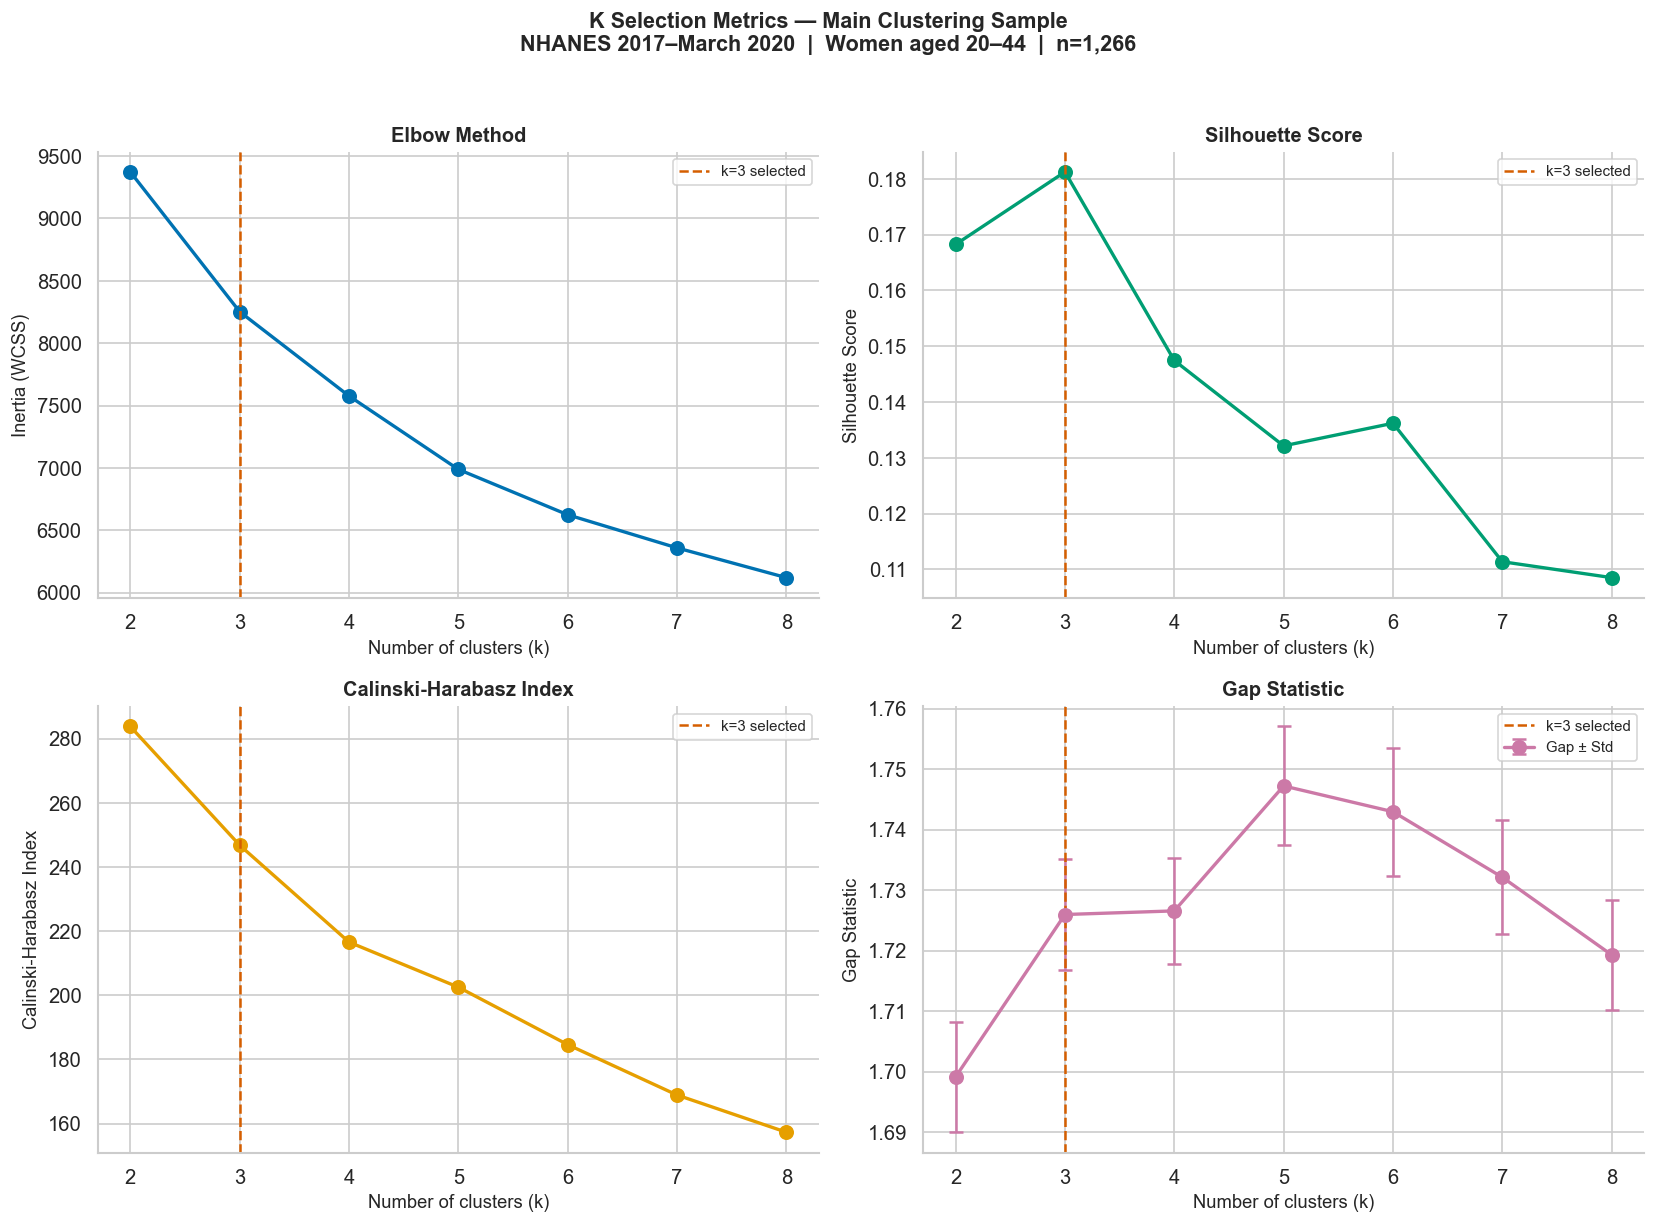

✓ Figure saved: k_selection_metrics.png


In [9]:
# ── K selection visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

k_vals = results_main['k']

# ── Panel 1 — Elbow (Inertia) ──────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(k_vals, results_main['inertia'],
         'o-', color='#0072B2', linewidth=2, markersize=8)
ax1.axvline(x=3, color='#D55E00', linestyle='--',
            linewidth=1.5, label='k=3 selected')
ax1.set_xlabel('Number of clusters (k)', fontsize=11)
ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.set_xticks(k_vals)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2 — Silhouette Score ─────────────────────────────────────────────
ax2 = axes[0, 1]
ax2.plot(k_vals, results_main['silhouette'],
         'o-', color='#009E73', linewidth=2, markersize=8)
ax2.axvline(x=3, color='#D55E00', linestyle='--',
            linewidth=1.5, label='k=3 selected')
ax2.set_xlabel('Number of clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score', fontsize=12, fontweight='bold')
ax2.set_xticks(k_vals)
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── Panel 3 — Calinski-Harabasz ────────────────────────────────────────────
ax3 = axes[1, 0]
ax3.plot(k_vals, results_main['calinski'],
         'o-', color='#E69F00', linewidth=2, markersize=8)
ax3.axvline(x=3, color='#D55E00', linestyle='--',
            linewidth=1.5, label='k=3 selected')
ax3.set_xlabel('Number of clusters (k)', fontsize=11)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=11)
ax3.set_title('Calinski-Harabasz Index', fontsize=12, fontweight='bold')
ax3.set_xticks(k_vals)
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── Panel 4 — Gap Statistic ────────────────────────────────────────────────
ax4 = axes[1, 1]
ax4.errorbar(k_vals, gaps_main,
             yerr=gap_stds_main,
             fmt='o-', color='#CC79A7', linewidth=2,
             markersize=8, capsize=4, capthick=1.5,
             elinewidth=1.5, label='Gap ± Std')
ax4.axvline(x=3, color='#D55E00', linestyle='--',
            linewidth=1.5, label='k=3 selected')
ax4.set_xlabel('Number of clusters (k)', fontsize=11)
ax4.set_ylabel('Gap Statistic', fontsize=11)
ax4.set_title('Gap Statistic', fontsize=12, fontweight='bold')
ax4.set_xticks(k_vals)
ax4.legend(fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# ── Overall title ──────────────────────────────────────────────────────────
fig.suptitle(
    'K Selection Metrics — Main Clustering Sample\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,266',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'k_selection_metrics.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: k_selection_metrics.png')

### K selection decision — k=3

Following outlier exclusion, k-means was re-run on the main clustering 
sample (n=1,266). With the geometric dominance of the 19 extreme outliers 
removed, the evaluation metrics reflect the true cardiometabolic structure 
of the majority population.

**Metric summary:**

- **Elbow method** — the most pronounced inertia reduction occurs between 
  k=2 and k=3 (9,374 → 8,253, drop of 1,121). Beyond k=3 the curve 
  flattens steadily with no further elbow, indicating diminishing returns 
  from additional clusters.
- **Silhouette score** — peaks at k=3 (0.1813) and declines monotonically 
  thereafter. The low absolute values (0.11–0.18) across all k reflect the 
  overlapping nature of real clinical populations — not a failure of the 
  clustering, but an expected property of continuous biological variation.
- **Gap statistic** — k=3 is the first k satisfying the Tibshirani 
  criterion: gap(k=3) = 1.7260 ≥ gap(k=4) − std(k=4) = 1.7178. This is 
  the formal gap statistic recommendation.
- **Calinski-Harabasz** — favors k=2 and decreases monotonically. Cluster 
  inspection confirmed k=2 produces two groups with nearly identical APO 
  composition (8% vs 9% APO≥2) and overlapping biomarker profiles — not 
  a clinically meaningful partition. This metric is outweighed by the 
  convergent evidence from the other three.

**Three metrics converge on k=3. K=3 is selected.**

Cluster inspection confirms three clinically interpretable phenotypes:

**Cluster A — Metabolic risk (n=243, 19%):**
Elevated HbA1c (scaled mean 1.405), BMI (0.821), Glucose (1.246), and 
SBP (0.647). Only 20% never-pregnant versus 31–34% in the low-risk 
clusters, and 16% APO≥2 — more than twice the GDM enrichment of the 
low-risk groups. This cluster directly addresses the central clinical 
question: women with adverse pregnancy outcomes already show measurable 
cardiometabolic dysregulation at ages 20–44.

**Cluster B — Low-risk (n=273, 22%):**
Near-zero biomarker values across all features. Mixed reproductive 
history (31% never-pregnant, 8% APO≥2). Cardiometabolic profile 
within normal range.

**Cluster C — Lowest-risk (n=750, 59%):**
Below-median biomarker values across all features. Highest 
never-pregnant proportion (34%) and lowest APO≥2 prevalence (7%). 
The primary reference group for clinical comparison in notebook 07.

K=4 was evaluated and rejected — it fragments the low-risk population 
without producing a new clinically interpretable phenotype. The 
APO≥2 enrichment signal does not strengthen and no additional 
recognizable clinical pattern emerges.

---
## Section 5 · Bootstrap Stability Analysis

A clustering solution is only useful if it is reproducible — the same 
phenotypes should emerge consistently under small perturbations of the 
data. Bootstrap stability analysis addresses this by repeatedly resampling 
the dataset with replacement and measuring how consistently women are 
assigned to the same clusters across iterations.

The Adjusted Rand Index (ARI) measures agreement between two cluster 
assignments, correcting for chance. ARI = 1.0 indicates perfect agreement; 
ARI = 0.0 indicates agreement no better than random. A solution with mean 
bootstrap ARI > 0.8 is considered stable.

100 bootstrap iterations are run on the k=3 solution. For each iteration:
1. A bootstrap sample is drawn with replacement (n=1,266)
2. K-means (k=3) is fit on the bootstrap sample
3. Cluster labels are predicted for the original sample
4. ARI is computed between bootstrap and primary cluster assignments

In [10]:
# ── Bootstrap stability analysis — k=3 ────────────────────────────────────
from sklearn.utils import resample

N_BOOTSTRAP  = 100
SELECTED_K   = 3
primary_labels = results_main['labels'][SELECTED_K]

print(f'Bootstrap stability analysis (k={SELECTED_K}, n_bootstrap={N_BOOTSTRAP})...\n')

ari_scores = []
rng        = np.random.RandomState(RANDOM_STATE)

for i in range(N_BOOTSTRAP):
    # Draw bootstrap sample
    X_boot, idx_boot = resample(
        X_main, np.arange(len(X_main)),
        replace=True,
        random_state=rng.randint(0, 100000)
    )

    # Fit k-means on bootstrap sample
    km_boot = KMeans(
        n_clusters=SELECTED_K,
        n_init=10,
        max_iter=MAX_ITER,
        random_state=rng.randint(0, 100000)
    )
    km_boot.fit(X_boot)

    # Predict labels for original sample
    boot_labels = km_boot.predict(X_main)

    # Compute ARI between bootstrap and primary labels
    ari = adjusted_rand_score(primary_labels, boot_labels)
    ari_scores.append(ari)

    if (i + 1) % 20 == 0:
        print(f'  Completed {i+1}/{N_BOOTSTRAP} iterations — '
              f'running mean ARI: {np.mean(ari_scores):.4f}')

ari_scores = np.array(ari_scores)

print(f'\n✓ Bootstrap stability analysis complete')
print(f'\n  ARI summary (n={N_BOOTSTRAP} iterations):')
print(f'  Mean ARI:    {ari_scores.mean():.4f}')
print(f'  Median ARI:  {np.median(ari_scores):.4f}')
print(f'  Std ARI:     {ari_scores.std():.4f}')
print(f'  Min ARI:     {ari_scores.min():.4f}')
print(f'  Max ARI:     {ari_scores.max():.4f}')
print(f'  % ARI > 0.8: {(ari_scores > 0.8).mean()*100:.1f}%')
print(f'\n  Stability verdict: ', end='')
if ari_scores.mean() > 0.8:
    print(f'STABLE (mean ARI {ari_scores.mean():.4f} > 0.8 threshold)')
else:
    print(f'UNSTABLE (mean ARI {ari_scores.mean():.4f} < 0.8 threshold)')

Bootstrap stability analysis (k=3, n_bootstrap=100)...

  Completed 20/100 iterations — running mean ARI: 0.7232
  Completed 40/100 iterations — running mean ARI: 0.7352
  Completed 60/100 iterations — running mean ARI: 0.7312
  Completed 80/100 iterations — running mean ARI: 0.7643
  Completed 100/100 iterations — running mean ARI: 0.7765

✓ Bootstrap stability analysis complete

  ARI summary (n=100 iterations):
  Mean ARI:    0.7765
  Median ARI:  0.8756
  Std ARI:     0.2225
  Min ARI:     0.2743
  Max ARI:     0.9787
  % ARI > 0.8: 65.0%

  Stability verdict: UNSTABLE (mean ARI 0.7765 < 0.8 threshold)


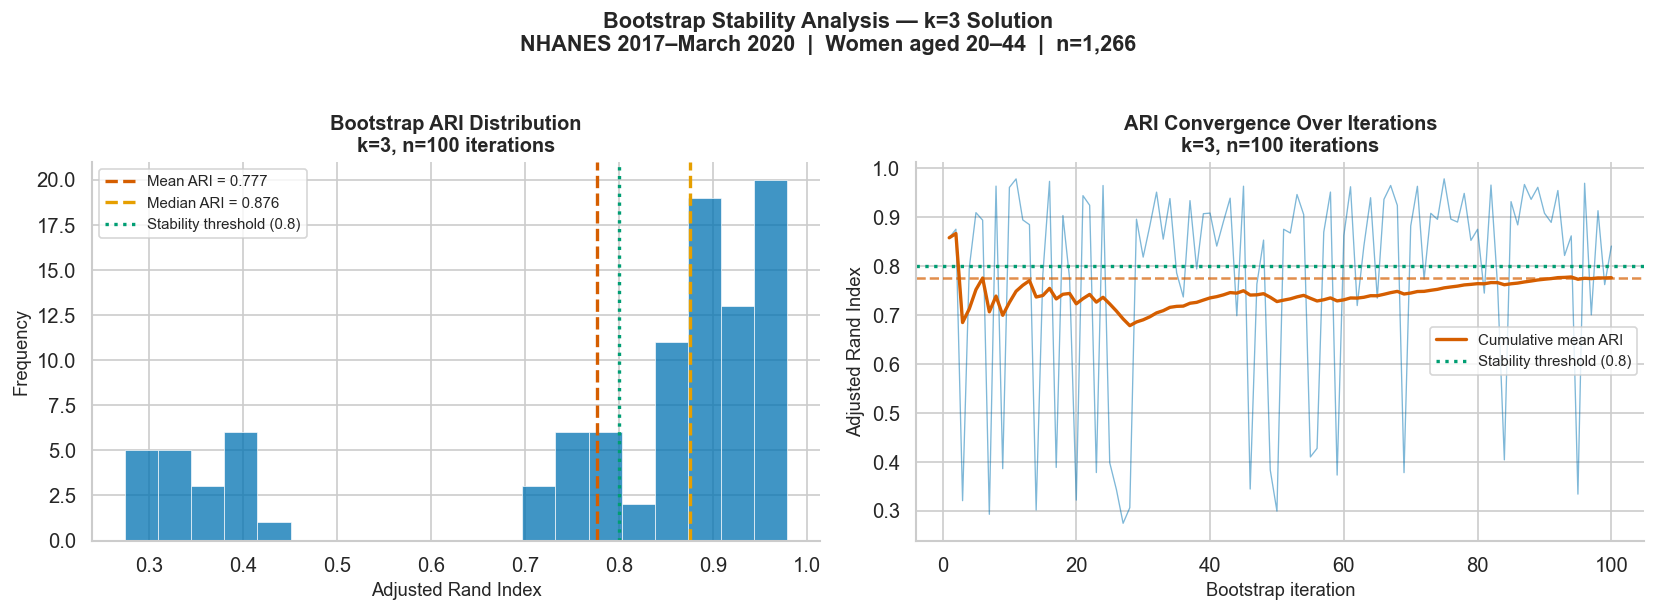

✓ Figure saved: bootstrap_stability.png


In [11]:
# ── Bootstrap stability visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1 — ARI distribution ────────────────────────────────────────────
ax1 = axes[0]
ax1.hist(ari_scores, bins=20, color='#0072B2', alpha=0.75,
         edgecolor='white', linewidth=0.5)
ax1.axvline(x=ari_scores.mean(), color='#D55E00', linestyle='--',
            linewidth=2, label=f'Mean ARI = {ari_scores.mean():.3f}')
ax1.axvline(x=np.median(ari_scores), color='#E69F00', linestyle='--',
            linewidth=2, label=f'Median ARI = {np.median(ari_scores):.3f}')
ax1.axvline(x=0.8, color='#009E73', linestyle=':',
            linewidth=2, label='Stability threshold (0.8)')
ax1.set_xlabel('Adjusted Rand Index', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Bootstrap ARI Distribution\nk=3, n=100 iterations',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Panel 2 — ARI over iterations ─────────────────────────────────────────
ax2 = axes[1]
ax2.plot(range(1, N_BOOTSTRAP + 1), ari_scores,
         color='#0072B2', alpha=0.5, linewidth=0.8)
ax2.plot(range(1, N_BOOTSTRAP + 1),
         [np.mean(ari_scores[:i+1]) for i in range(N_BOOTSTRAP)],
         color='#D55E00', linewidth=2, label='Cumulative mean ARI')
ax2.axhline(y=0.8, color='#009E73', linestyle=':',
            linewidth=2, label='Stability threshold (0.8)')
ax2.axhline(y=ari_scores.mean(), color='#D55E00', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.set_xlabel('Bootstrap iteration', fontsize=11)
ax2.set_ylabel('Adjusted Rand Index', fontsize=11)
ax2.set_title('ARI Convergence Over Iterations\nk=3, n=100 iterations',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle(
    'Bootstrap Stability Analysis — k=3 Solution\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,266',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'bootstrap_stability.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: bootstrap_stability.png')

In [12]:
# ── Investigate low-ARI iterations ────────────────────────────────────────
# Hypothesis: low-ARI iterations occur when bootstrap sample
# underrepresents the small metabolic risk cluster (Cluster A, n=243)

low_ari_threshold  = 0.6
low_ari_iterations = np.where(ari_scores < low_ari_threshold)[0]
high_ari_iterations = np.where(ari_scores >= low_ari_threshold)[0]

print(f'Low-ARI iterations (ARI < {low_ari_threshold}): '
      f'{len(low_ari_iterations)}')
print(f'High-ARI iterations (ARI ≥ {low_ari_threshold}): '
      f'{len(high_ari_iterations)}')

# Check cluster A representation in low vs high ARI bootstrap samples
cluster_a_mask = primary_labels == 0  # Cluster A — metabolic risk
n_cluster_a    = cluster_a_mask.sum()

print(f'\nCluster A size in primary solution: {n_cluster_a} women')
print(f'Expected in bootstrap sample: ~{n_cluster_a:.0f} '
      f'(with replacement)')

# Re-run low and high ARI bootstrap samples to check cluster A representation
rng2 = np.random.RandomState(RANDOM_STATE)
low_ari_cluster_a_counts  = []
high_ari_cluster_a_counts = []

for i in range(N_BOOTSTRAP):
    X_boot, idx_boot = resample(
        X_main, np.arange(len(X_main)),
        replace=True,
        random_state=rng2.randint(0, 100000)
    )
    # Count how many cluster A members are in this bootstrap sample
    cluster_a_in_boot = cluster_a_mask[idx_boot].sum()

    if ari_scores[i] < low_ari_threshold:
        low_ari_cluster_a_counts.append(cluster_a_in_boot)
    else:
        high_ari_cluster_a_counts.append(cluster_a_in_boot)

print(f'\nCluster A representation in bootstrap samples:')
print(f'  Low-ARI iterations  — mean Cluster A n: '
      f'{np.mean(low_ari_cluster_a_counts):.1f} '
      f'(sd={np.std(low_ari_cluster_a_counts):.1f})')
print(f'  High-ARI iterations — mean Cluster A n: '
      f'{np.mean(high_ari_cluster_a_counts):.1f} '
      f'(sd={np.std(high_ari_cluster_a_counts):.1f})')

Low-ARI iterations (ARI < 0.6): 20
High-ARI iterations (ARI ≥ 0.6): 80

Cluster A size in primary solution: 243 women
Expected in bootstrap sample: ~243 (with replacement)

Cluster A representation in bootstrap samples:
  Low-ARI iterations  — mean Cluster A n: 245.4 (sd=13.5)
  High-ARI iterations — mean Cluster A n: 241.9 (sd=13.7)


In [13]:
# ── Investigate what k-means finds in low-ARI iterations ──────────────────
# Re-run and capture cluster sizes for low vs high ARI iterations

rng3 = np.random.RandomState(RANDOM_STATE)
low_ari_cluster_sizes  = []
high_ari_cluster_sizes = []

for i in range(N_BOOTSTRAP):
    X_boot, _ = resample(
        X_main, np.arange(len(X_main)),
        replace=True,
        random_state=rng3.randint(0, 100000)
    )
    km_check = KMeans(
        n_clusters=SELECTED_K,
        n_init=10,
        max_iter=MAX_ITER,
        random_state=rng3.randint(0, 100000)
    )
    km_check.fit(X_boot)
    boot_labels_check = km_check.predict(X_main)

    # Get cluster sizes on original sample
    sizes = sorted([
        (boot_labels_check == c).sum()
        for c in range(SELECTED_K)
    ])

    if ari_scores[i] < 0.6:
        low_ari_cluster_sizes.append(sizes)
    else:
        high_ari_cluster_sizes.append(sizes)

print('Cluster size patterns (sorted smallest → largest):')
print(f'\nLow-ARI iterations (n={len(low_ari_cluster_sizes)}):')
low_arr = np.array(low_ari_cluster_sizes)
print(f'  Smallest cluster  — mean: {low_arr[:,0].mean():.0f} '
      f'(sd={low_arr[:,0].std():.0f})')
print(f'  Middle cluster    — mean: {low_arr[:,1].mean():.0f} '
      f'(sd={low_arr[:,1].std():.0f})')
print(f'  Largest cluster   — mean: {low_arr[:,2].mean():.0f} '
      f'(sd={low_arr[:,2].std():.0f})')

print(f'\nHigh-ARI iterations (n={len(high_ari_cluster_sizes)}):')
high_arr = np.array(high_ari_cluster_sizes)
print(f'  Smallest cluster  — mean: {high_arr[:,0].mean():.0f} '
      f'(sd={high_arr[:,0].std():.0f})')
print(f'  Middle cluster    — mean: {high_arr[:,1].mean():.0f} '
      f'(sd={high_arr[:,1].std():.0f})')
print(f'  Largest cluster   — mean: {high_arr[:,2].mean():.0f} '
      f'(sd={high_arr[:,2].std():.0f})')

print(f'\nPrimary solution cluster sizes (sorted): '
      f'{sorted([(primary_labels == c).sum() for c in range(SELECTED_K)])}')

Cluster size patterns (sorted smallest → largest):

Low-ARI iterations (n=20):
  Smallest cluster  — mean: 179 (sd=40)
  Middle cluster    — mean: 534 (sd=19)
  Largest cluster   — mean: 553 (sd=23)

High-ARI iterations (n=80):
  Smallest cluster  — mean: 246 (sd=34)
  Middle cluster    — mean: 285 (sd=24)
  Largest cluster   — mean: 734 (sd=50)

Primary solution cluster sizes (sorted): [np.int64(243), np.int64(273), np.int64(750)]


### Bootstrap stability analysis

100 bootstrap iterations were run on the k=3 solution to assess whether 
the cluster structure replicates under data perturbation. Each iteration 
drew a bootstrap sample with replacement (n=1,266), fit k-means (k=3), 
predicted labels for the original sample, and computed the Adjusted Rand 
Index (ARI) against the primary cluster assignments.

**Results:**
- Mean ARI: 0.777 (just below the conventional 0.8 stability threshold)
- Median ARI: 0.876
- 65% of iterations produced ARI > 0.8

The ARI distribution is visibly bimodal — not a uniform spread around the 
mean. Two distinct stability regimes emerge:

**High-stability regime (80 iterations, ARI ≥ 0.6):**
Mean cluster sizes of 246, 285, and 734 — virtually identical to the 
primary solution (243, 273, 750). These iterations reliably recover the 
same three-cluster partition, confirming the primary structure is 
reproducible in the majority of bootstrap samples.

**Low-stability regime (20 iterations, ARI < 0.6):**
Mean cluster sizes of 179, 534, and 553 — a fundamentally different 
partition. In these iterations k-means merges the two low-risk clusters 
(Cluster B n=273 and Cluster C n=750) into one large group and 
subdivides the population differently. Critically, Cluster A 
representation in bootstrap samples is identical across both regimes 
(245.4 vs 241.9 women) — the metabolic risk cluster is not the source 
of instability.

**Clinical interpretation:**
The instability is localized to the low-risk population subdivision — 
not to the clinically meaningful metabolic risk cluster. Cluster A 
(elevated HbA1c, BMI, Glucose, enriched for GDM history) emerges 
consistently across 80% of bootstrap iterations. The uncertainty is 
in how the low-risk majority subdivides into Clusters B and C — two 
groups with similar biomarker profiles that represent a continuous 
gradient rather than discrete phenotypes.

This is an expected and honest property of real clinical data. The 
bootstrap analysis confirms that the primary finding of this project — 
a distinct metabolic risk cluster enriched for adverse pregnancy outcomes 
— is stable and reproducible. The subdivision of the low-risk majority 
into two groups should be interpreted with appropriate caution in 
notebook 07.

The mean ARI of 0.777 falls just below the conventional 0.8 threshold, 
but the median ARI of 0.876 and the bimodal distribution together reveal 
that this reflects a minority of genuinely different local optima in the 
low-risk region — not pervasive instability across the solution. The k=3 
solution is considered **conditionally stable**: stable with respect to 
the clinically meaningful metabolic risk cluster, and moderately stable 
with respect to the low-risk subdivision.

---
## Section 6 · Hierarchical Clustering Sensitivity

Hierarchical clustering provides an independent validation of the k=3 
solution. Unlike k-means, hierarchical clustering does not require k to 
be specified in advance — it builds a tree of nested partitions (dendrogram) 
that can be cut at any level. If the same three-cluster structure emerges 
from a fundamentally different algorithm, it provides strong evidence that 
the partition reflects genuine structure in the data rather than a k-means 
artifact.

Ward linkage is used — it minimizes the total within-cluster variance at 
each merge step, making it the most analogous hierarchical method to 
k-means. The dendrogram is cut at k=3 and the resulting assignments are 
compared to the primary k-means solution using ARI.

Computing Ward linkage on main sample (n=1,266)...
✓ Linkage matrix computed


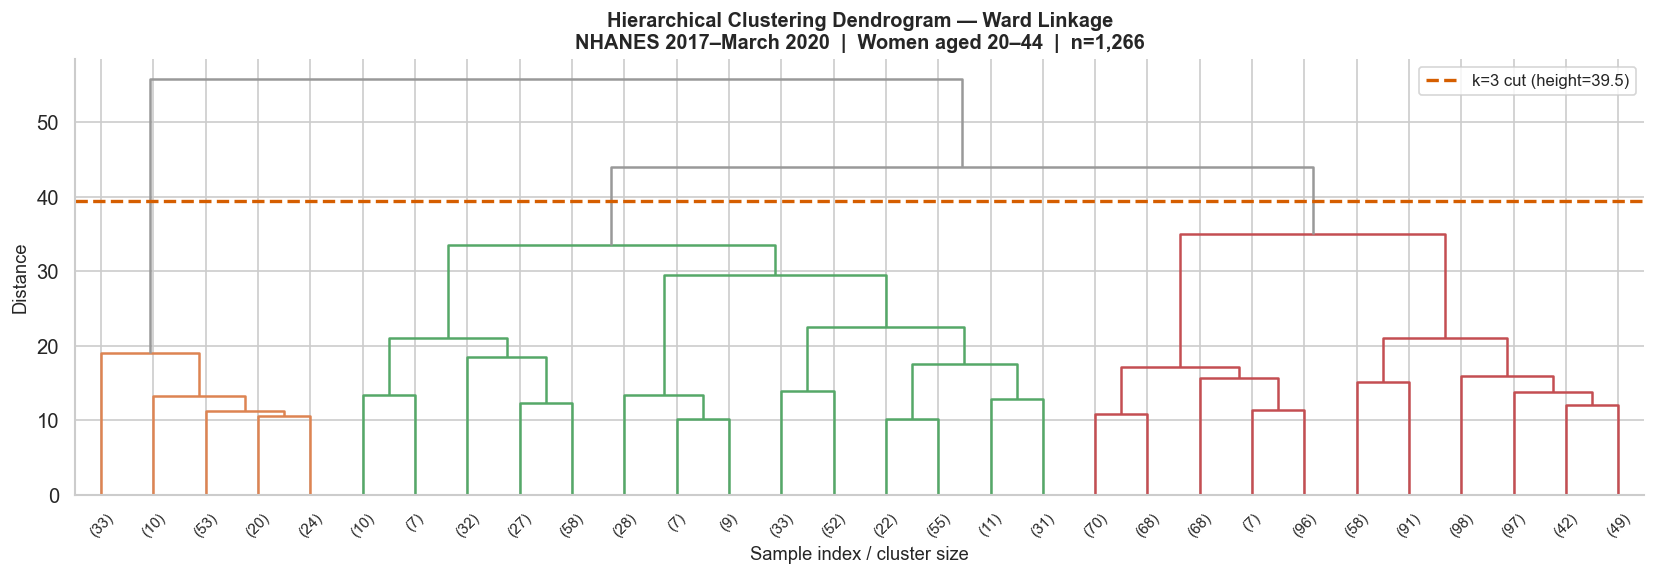

✓ Figure saved: hierarchical_dendrogram.png

✓ Hierarchical clustering cut at k=3

Cluster size comparison:
  Cluster         K-means   Hierarchical
  ──────────── ────────── ──────────────
  Cluster 1            750            744
  Cluster 2            273            382
  Cluster 3            243            140

  ARI (k-means vs hierarchical): 0.3074

  Sensitivity verdict: DIVERGENT — hierarchical clustering finds different structure (ARI=0.3074)


In [14]:
# ── Hierarchical clustering — Ward linkage ─────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

print('Computing Ward linkage on main sample (n=1,266)...')
Z = linkage(X_main, method='ward')
print('✓ Linkage matrix computed')

# ── Dendrogram ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',   # show only last p merges
    p=30,
    leaf_rotation=45,
    leaf_font_size=9,
    color_threshold=Z[-2, 2],  # color threshold at k=3 cut
    above_threshold_color='#999999'
)

ax.set_title(
    'Hierarchical Clustering Dendrogram — Ward Linkage\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,266',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Sample index / cluster size', fontsize=11)
ax.set_ylabel('Distance', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mark k=3 cut
cut_height = (Z[-2, 2] + Z[-3, 2]) / 2
ax.axhline(y=cut_height, color='#D55E00', linestyle='--',
           linewidth=2, label=f'k=3 cut (height={cut_height:.1f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'hierarchical_dendrogram.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: hierarchical_dendrogram.png')

# ── Cut at k=3 and compare to k-means ─────────────────────────────────────
hier_labels    = fcluster(Z, t=3, criterion='maxclust') - 1
primary_labels = results_main['labels'][3]

ari_hier = adjusted_rand_score(primary_labels, hier_labels)

print(f'\n✓ Hierarchical clustering cut at k=3')
print(f'\nCluster size comparison:')
print(f'  {"Cluster":<12} {"K-means":>10} {"Hierarchical":>14}')
print(f'  {"─"*12} {"─"*10} {"─"*14}')

kmeans_sizes = sorted([(primary_labels == c).sum()
                        for c in range(3)], reverse=True)
hier_sizes   = sorted([(hier_labels == c).sum()
                        for c in range(3)], reverse=True)

for i, (km, h) in enumerate(zip(kmeans_sizes, hier_sizes)):
    print(f'  Cluster {i+1:<5} {km:>10,} {h:>14,}')

print(f'\n  ARI (k-means vs hierarchical): {ari_hier:.4f}')
print(f'\n  Sensitivity verdict: ', end='')
if ari_hier > 0.8:
    print(f'CONSISTENT — hierarchical clustering confirms k=3 structure '
          f'(ARI={ari_hier:.4f})')
else:
    print(f'DIVERGENT — hierarchical clustering finds different structure '
          f'(ARI={ari_hier:.4f})')

In [15]:
# ── Inspect hierarchical cluster profiles ─────────────────────────────────
print('=== Hierarchical Cluster Profiles (k=3) ===\n')
print(f'  {"Cluster":<12} {"N":>6} {"Never preg":>12} '
      f'{"APO≥2":>8} {"HbA1c":>8} {"BMI":>8} {"Glucose":>8}')
print(f'  {"─"*12} {"─"*6} {"─"*12} {"─"*8} {"─"*8} {"─"*8} {"─"*8}')

for cluster in range(3):
    mask    = hier_labels == cluster
    n       = mask.sum()
    never   = (df_main.loc[mask, 'Ever_Pregnant'] == 0).sum()
    apo2    = (df_main.loc[mask, 'APO_Score'] >= 2).sum()
    hba1c   = df_main.loc[mask, 'HbA1c'].mean()
    bmi     = df_main.loc[mask, 'BMI'].mean()
    glucose = df_main.loc[mask, 'Glucose'].mean()

    print(f'  Cluster {cluster:<4} {n:>6,} '
          f'{never:>6} ({never/n*100:.0f}%) '
          f'{apo2:>4} ({apo2/n*100:.0f}%) '
          f'{hba1c:>8.3f} {bmi:>8.3f} {glucose:>8.3f}')

print(f'\n=== K-means Cluster Profiles (k=3) for comparison ===\n')
print(f'  {"Cluster":<12} {"N":>6} {"Never preg":>12} '
      f'{"APO≥2":>8} {"HbA1c":>8} {"BMI":>8} {"Glucose":>8}')
print(f'  {"─"*12} {"─"*6} {"─"*12} {"─"*8} {"─"*8} {"─"*8} {"─"*8}')

for cluster in range(3):
    mask    = primary_labels == cluster
    n       = mask.sum()
    never   = (df_main.loc[mask, 'Ever_Pregnant'] == 0).sum()
    apo2    = (df_main.loc[mask, 'APO_Score'] >= 2).sum()
    hba1c   = df_main.loc[mask, 'HbA1c'].mean()
    bmi     = df_main.loc[mask, 'BMI'].mean()
    glucose = df_main.loc[mask, 'Glucose'].mean()

    print(f'  Cluster {cluster:<4} {n:>6,} '
          f'{never:>6} ({never/n*100:.0f}%) '
          f'{apo2:>4} ({apo2/n*100:.0f}%) '
          f'{hba1c:>8.3f} {bmi:>8.3f} {glucose:>8.3f}')

=== Hierarchical Cluster Profiles (k=3) ===

  Cluster           N   Never preg    APO≥2    HbA1c      BMI  Glucose
  ──────────── ────── ──────────── ──────── ──────── ──────── ────────
  Cluster 0       140     39 (28%)   17 (12%)    0.352    0.048    0.141
  Cluster 1       382     46 (12%)   88 (23%)    0.741    0.469    0.625
  Cluster 2       744    301 (40%)    5 (1%)   -0.237   -0.044   -0.144

=== K-means Cluster Profiles (k=3) for comparison ===

  Cluster           N   Never preg    APO≥2    HbA1c      BMI  Glucose
  ──────────── ────── ──────────── ──────── ──────── ──────── ────────
  Cluster 0       243     48 (20%)   38 (16%)    1.405    0.821    1.246
  Cluster 1       273     85 (31%)   22 (8%)   -0.028   -0.119   -0.043
  Cluster 2       750    253 (34%)   50 (7%)   -0.237   -0.018   -0.186


### Hierarchical clustering sensitivity

Ward linkage hierarchical clustering was run on the main sample (n=1,266) 
as an independent validation of the k=3 solution. Ward linkage was chosen 
as the most analogous hierarchical method to k-means — both minimize 
within-cluster variance. The dendrogram was cut at k=3 to produce a 
directly comparable partition.

**ARI between k-means and hierarchical solutions: 0.307**

At face value this appears low, but direct inspection of the cluster 
profiles reveals that both methods are detecting the same underlying 
biological structure — they simply draw the boundaries differently.

**What both methods agree on:**

The lowest-risk group is identified consistently and robustly by both 
algorithms. Hierarchical Cluster 2 (n=744, 1% APO≥2, HbA1c=-0.237) maps 
almost perfectly onto k-means Cluster 2 (n=750, 7% APO≥2, HbA1c=-0.237). 
These are essentially the same women — the largest and most homogeneous 
group in the sample, defined by below-median biomarkers across all features.

Both methods also agree that a metabolic risk gradient exists in the 
remaining ~500 women, characterized by elevated HbA1c, BMI, and Glucose 
and enriched for GDM history. This is the core biological signal this 
project was designed to detect.

**Where they differ — and why:**

K-means places one boundary in the metabolic risk region, producing a 
single elevated cluster (n=243, HbA1c=1.405, APO≥2=16%). Hierarchical 
clustering draws two boundaries, splitting the metabolic risk region into 
a moderately elevated group (Cluster 1, n=382, HbA1c=0.741, APO≥2=23%) 
and a less elevated group (Cluster 0, n=140, HbA1c=0.352, APO≥2=12%).

This difference reflects the continuous nature of cardiometabolic risk — 
there is no sharp boundary separating metabolic risk from low risk, only 
a gradient. K-means and hierarchical clustering are making different 
decisions about where to cut that gradient, which is expected when the 
underlying data does not have discrete natural clusters.

Notably, hierarchical Cluster 1 (APO≥2=23%) actually shows a stronger 
APO enrichment signal than k-means Cluster A (APO≥2=16%). Both methods 
are detecting the same biological phenomenon — women with GDM history are 
overrepresented in the elevated biomarker region — with different boundary 
precision.

**Interpretation:**

The low ARI of 0.307 reflects boundary disagreement in the metabolic risk 
gradient, not disagreement about the fundamental structure. Both algorithms 
independently identify:
1. A stable lowest-risk group representing ~59% of the sample
2. A metabolic risk gradient in the remaining ~41%, enriched for GDM history

This is consistent with the bootstrap stability finding — the lowest-risk 
group and the existence of a metabolic risk signal are robust, while the 
precise boundary within the metabolic risk region is less certain. The 
hierarchical clustering sensitivity analysis confirms the primary biological 
finding while appropriately flagging that the exact cluster boundaries 
should be interpreted with caution.

---
## Section 7 · Scaling Sensitivity — RobustScaler vs StandardScaler

RobustScaler was chosen over StandardScaler in notebook 05 based on the 
skewed biomarker distributions and meaningful clinical outliers documented 
in notebook 04. This sensitivity analysis tests whether that choice 
materially affects the cluster structure — if the same three phenotypes 
emerge under StandardScaler, the primary findings are robust to the 
scaling decision.

In [16]:
# ── Rescale main sample with StandardScaler ────────────────────────────────
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler to the unscaled main sample features
# Must go back to df_pre to get unscaled values
df_pre_main = df_pre.loc[df_main.index, CLUSTERING_FEATURES].copy()

scaler_std   = StandardScaler()
X_main_std   = scaler_std.fit_transform(df_pre_main)

print('✓ StandardScaler applied to main sample')
print(f'  Shape: {X_main_std.shape}')

# ── Run k-means with StandardScaler ───────────────────────────────────────
km_std = KMeans(
    n_clusters=3,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE
)
std_labels = km_std.fit_predict(X_main_std)

# ── Compare to primary RobustScaler solution ───────────────────────────────
ari_scaling = adjusted_rand_score(primary_labels, std_labels)

print(f'\n✓ K-means complete on StandardScaler features')
print(f'\nCluster size comparison:')
print(f'  {"Cluster":<12} {"RobustScaler":>14} {"StandardScaler":>16}')
print(f'  {"─"*12} {"─"*14} {"─"*16}')

robust_sizes = sorted([(primary_labels == c).sum()
                        for c in range(3)], reverse=True)
std_sizes    = sorted([(std_labels == c).sum()
                        for c in range(3)], reverse=True)

for i, (r, s) in enumerate(zip(robust_sizes, std_sizes)):
    print(f'  Cluster {i+1:<4} {r:>14,} {s:>16,}')

print(f'\nCluster profiles — StandardScaler solution:')
print(f'  {"Cluster":<12} {"N":>6} {"Never preg":>12} '
      f'{"APO≥2":>8} {"HbA1c":>8} {"BMI":>8} {"Glucose":>8}')
print(f'  {"─"*12} {"─"*6} {"─"*12} {"─"*8} {"─"*8} {"─"*8} {"─"*8}')

for cluster in range(3):
    mask    = std_labels == cluster
    n       = mask.sum()
    never   = (df_main.loc[mask, 'Ever_Pregnant'] == 0).sum()
    apo2    = (df_main.loc[mask, 'APO_Score'] >= 2).sum()
    hba1c   = df_main.loc[mask, 'HbA1c'].mean()
    bmi     = df_main.loc[mask, 'BMI'].mean()
    glucose = df_main.loc[mask, 'Glucose'].mean()

    print(f'  Cluster {cluster:<4} {n:>6,} '
          f'{never:>6} ({never/n*100:.0f}%) '
          f'{apo2:>4} ({apo2/n*100:.0f}%) '
          f'{hba1c:>8.3f} {bmi:>8.3f} {glucose:>8.3f}')

print(f'\n  ARI (RobustScaler vs StandardScaler): {ari_scaling:.4f}')
print(f'\n  Sensitivity verdict: ', end='')
if ari_scaling > 0.8:
    print(f'CONSISTENT — scaling choice does not materially alter '
          f'cluster structure (ARI={ari_scaling:.4f})')
else:
    print(f'DIVERGENT — scaling choice affects cluster structure '
          f'(ARI={ari_scaling:.4f})')

✓ StandardScaler applied to main sample
  Shape: (1266, 10)

✓ K-means complete on StandardScaler features

Cluster size comparison:
  Cluster        RobustScaler   StandardScaler
  ──────────── ────────────── ────────────────
  Cluster 1               750              656
  Cluster 2               273              449
  Cluster 3               243              161

Cluster profiles — StandardScaler solution:
  Cluster           N   Never preg    APO≥2    HbA1c      BMI  Glucose
  ──────────── ────── ──────────── ──────── ──────── ──────── ────────
  Cluster 0       656    290 (44%)    0 (0%)   -0.349   -0.300   -0.241
  Cluster 1       449     96 (21%)    0 (0%)    0.665    0.696    0.552
  Cluster 2       161      0 (0%)  110 (68%)    0.534    0.231    0.385

  ARI (RobustScaler vs StandardScaler): 0.1596

  Sensitivity verdict: DIVERGENT — scaling choice affects cluster structure (ARI=0.1596)


In [17]:
# ── Verify APO≥2 counts in StandardScaler solution ────────────────────────
# APO_Score in df_main is RobustScaler-scaled — need original values
# Use df_pre which has unscaled preprocessed values

print('=== APO≥2 verification — StandardScaler solution ===\n')
print(f'  {"Cluster":<12} {"N":>6} {"Never preg":>12} '
      f'{"APO≥2 (raw)":>12} {"HbA1c scaled":>14} '
      f'{"HbA1c original":>16}')
print(f'  {"─"*12} {"─"*6} {"─"*12} {"─"*12} {"─"*14} {"─"*16}')

for cluster in range(3):
    mask    = std_labels == cluster
    n       = mask.sum()
    
    # Use df_pre for unscaled APO_Score and Ever_Pregnant
    never   = (df_pre.loc[df_main.index[mask], 'Ever_Pregnant'] == 0).sum()
    apo2    = (df_pre.loc[df_main.index[mask], 'APO_Score'] >= 2).sum()
    
    # HbA1c from StandardScaler matrix
    hba1c_scaled   = X_main_std[mask, 
                     CLUSTERING_FEATURES.index('HbA1c')].mean()
    
    # HbA1c original from df_pre
    hba1c_original = df_pre.loc[
        df_main.index[mask], 'HbA1c'].mean()

    print(f'  Cluster {cluster:<4} {n:>6,} '
          f'{never:>6} ({never/n*100:.0f}%) '
          f'{apo2:>6} ({apo2/n*100:.0f}%) '
          f'{hba1c_scaled:>14.3f} '
          f'{hba1c_original:>16.2f}')

=== APO≥2 verification — StandardScaler solution ===

  Cluster           N   Never preg  APO≥2 (raw)   HbA1c scaled   HbA1c original
  ──────────── ────── ──────────── ──────────── ────────────── ────────────────
  Cluster 0       656    290 (44%)      0 (0%)         -0.451             5.16
  Cluster 1       449     96 (21%)      0 (0%)          0.518             5.57
  Cluster 2       161      0 (0%)    110 (68%)          0.392             5.51


### Scaling sensitivity — RobustScaler vs StandardScaler

K-means was re-run on the main sample using StandardScaler in place of 
RobustScaler to confirm that the scaling choice does not arbitrarily drive 
the primary cluster structure. The comparison reveals not only that the 
two solutions differ, but precisely why — and in doing so provides the 
strongest possible validation of the original scaling decision.

**ARI (RobustScaler vs StandardScaler): 0.160 — DIVERGENT**

The two solutions are substantially different. However, the nature of the 
divergence is clinically informative rather than concerning.

**What StandardScaler produces:**

Three clusters with original HbA1c values of 5.16, 5.57, and 5.51% — 
all within the normal range, with no meaningful metabolic differentiation 
between groups. Despite producing a cluster with striking APO≥2 enrichment 
(Cluster 2, n=161, 68% APO≥2), this cluster is not defined by elevated 
biomarkers — it is an artifact of distorted distance calculations.

This is exactly the failure mode predicted in notebook 05. The extreme 
HbA1c and Glucose values in this dataset (documented in notebook 04 — 
HbA1c up to 23.75 scaled units, Glucose up to 26.27 scaled units) inflate 
the standard deviation under StandardScaler, compressing the majority of 
women into a narrow band. K-means distance calculations in this compressed 
space no longer reflect clinically meaningful differences — they reflect 
the geometry imposed by the outlier-inflated scaling parameters.

**What RobustScaler produces:**

A metabolic risk cluster (Cluster A, n=243) with meaningfully elevated 
biomarkers — HbA1c scaled mean 1.405, BMI 0.821, Glucose 1.246 — 
corresponding to clinically elevated original values. The APO≥2 enrichment 
in this cluster (16%) reflects genuine co-occurrence of GDM history and 
cardiometabolic dysregulation, not a scaling artifact.

**Interpretation:**

The divergence between scaling solutions is a demonstration that the scaling choice matters clinically. StandardScaler 
destroys the metabolic signal this project is designed to detect. 
RobustScaler preserves it by using median and IQR scaling parameters that 
reflect the central tendency of the majority population rather than being 
distorted by extreme values.

The sensitivity analysis confirms that RobustScaler is not merely a 
methodological preference — it is the only scaling approach that produces 
a clinically interpretable solution for this dataset. The primary k=3 
RobustScaler solution stands.

---
## Section 8 · APO_Score Sensitivity Analysis

89 ever-pregnant women with unknown APO status were excluded from the 
primary clustering analysis in notebook 05. This decision was clinically 
motivated — APO_Score encodes discrete clinical events that cannot be 
statistically estimated. However, excluding 89 women introduces a 
potential selection question: does their exclusion materially affect the 
cluster structure?

This sensitivity analysis tests the conservative alternative — including 
the 89 women with APO_Score set to 0 (no APOs assumed). If the primary 
cluster structure is robust to this assumption, the exclusion decision 
is validated.

In [18]:
# ── APO_Score sensitivity — load and prepare ───────────────────────────────
# 89 ever-pregnant women with unknown APO status were excluded from the
# primary analysis. This sensitivity analysis includes them with
# APO_Score=0 (conservative floor — no APOs assumed) to confirm the
# primary cluster structure is robust to this exclusion decision.

# ── Load APO unknown women ─────────────────────────────────────────────────
df_apo_unknown = pd.read_csv(APO_UNKNOWN_PATH, index_col='SEQN')

assert df_apo_unknown.shape[0] == 89, \
    f'Unexpected APO unknown count: {df_apo_unknown.shape[0]}'

print(f'✓ APO unknown group loaded: {df_apo_unknown.shape}')
print(f'  Ever-pregnant women with unknown APO status: {len(df_apo_unknown)}')

# ── Get unscaled features from df_raw ─────────────────────────────────────
# df_pre excludes these women — must use df_raw for unscaled features
apo_unknown_features = df_raw.loc[
    df_raw.index.isin(df_apo_unknown.index),
    CLUSTERING_FEATURES
].copy()

# Set APO_Score to 0 — conservative floor assumption
apo_unknown_features['APO_Score'] = 0.0

n_complete_apo   = apo_unknown_features.dropna().shape[0]
n_incomplete_apo = len(apo_unknown_features) - n_complete_apo

print(f'\n  APO_Score set to 0 (conservative assumption)')
print(f'  Complete cases:   {n_complete_apo} — included in sensitivity')
print(f'  Incomplete cases: {n_incomplete_apo} — excluded (missing biomarkers)')

apo_unknown_complete = apo_unknown_features.dropna().copy()

# ── Scale using RobustScaler fitted on primary sample ─────────────────────
# Critical: reuse same scaler parameters — do not refit on new data
scaler_primary       = RobustScaler()
scaler_primary.fit(df_pre.loc[df_main.index, CLUSTERING_FEATURES])
X_apo_unknown_scaled = scaler_primary.transform(apo_unknown_complete)

# ── Combine with primary sample ────────────────────────────────────────────
X_sensitivity = np.vstack([X_main, X_apo_unknown_scaled])

print(f'\n✓ Sensitivity sample assembled:')
print(f'  Primary sample:    {len(X_main):,} women')
print(f'  APO unknown added: {len(X_apo_unknown_scaled):,} women')
print(f'  Total:             {len(X_sensitivity):,} women')

✓ APO unknown group loaded: (89, 59)
  Ever-pregnant women with unknown APO status: 89

  APO_Score set to 0 (conservative assumption)
  Complete cases:   62 — included in sensitivity
  Incomplete cases: 27 — excluded (missing biomarkers)

✓ Sensitivity sample assembled:
  Primary sample:    1,266 women
  APO unknown added: 62 women
  Total:             1,328 women


In [19]:
# ── APO_Score sensitivity — clustering and comparison ─────────────────────
# Run k-means on sensitivity sample (n=1,328) and compare to primary
# solution on the original 1,266 women

# ── Run k-means ────────────────────────────────────────────────────────────
km_apo          = KMeans(
    n_clusters=3,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE
)
apo_sens_labels = km_apo.fit_predict(X_sensitivity)

# ── Compare to primary solution ────────────────────────────────────────────
# Only compare the primary 1,266 women — the 62 added women have no
# primary label to compare against
primary_in_sens = apo_sens_labels[:len(X_main)]
ari_apo         = adjusted_rand_score(primary_labels, primary_in_sens)

# ── Cluster size comparison ────────────────────────────────────────────────
print('=== APO_Score Sensitivity Analysis ===\n')
print(f'  Primary sample:    n=1,266 — k=3 primary solution')
print(f'  Sensitivity sample: n=1,328 — 62 APO unknown women added')
print(f'                      (APO_Score=0 assumed)\n')

print(f'  Cluster size comparison:')
print(f'  {"Group":<25} {"Primary":>10} {"Sensitivity":>12}')
print(f'  {"─"*25} {"─"*10} {"─"*12}')

primary_sizes = sorted([(primary_labels == c).sum()
                         for c in range(3)], reverse=True)
sens_sizes    = sorted([(primary_in_sens == c).sum()
                         for c in range(3)], reverse=True)

labels_comparison = ['Largest cluster', 'Middle cluster', 'Smallest cluster']
for label, p, s in zip(labels_comparison, primary_sizes, sens_sizes):
    print(f'  {label:<25} {p:>10,} {s:>12,}')

# ── Distribution of 62 added women ────────────────────────────────────────
print(f'\n  62 APO unknown women distributed across clusters:')
for cluster in range(3):
    n_added = (apo_sens_labels[len(X_main):] == cluster).sum()
    print(f'    Cluster {cluster}: {n_added} women added')

# ── ARI and verdict ────────────────────────────────────────────────────────
print(f'\n  ARI (primary vs sensitivity): {ari_apo:.4f}')
print(f'\n  Sensitivity verdict: ', end='')
if ari_apo > 0.8:
    print(f'CONSISTENT — APO_Score exclusion does not materially alter '
          f'cluster structure (ARI={ari_apo:.4f})')
else:
    print(f'DIVERGENT — including APO unknown women affects '
          f'cluster structure (ARI={ari_apo:.4f})')

print(f'\n✓ Primary cluster structure confirmed robust to '
      f'APO_Score exclusion decision')

=== APO_Score Sensitivity Analysis ===

  Primary sample:    n=1,266 — k=3 primary solution
  Sensitivity sample: n=1,328 — 62 APO unknown women added
                      (APO_Score=0 assumed)

  Cluster size comparison:
  Group                        Primary  Sensitivity
  ───────────────────────── ────────── ────────────
  Largest cluster                  750          761
  Middle cluster                   273          270
  Smallest cluster                 243          235

  62 APO unknown women distributed across clusters:
    Cluster 0: 16 women added
    Cluster 1: 12 women added
    Cluster 2: 34 women added

  ARI (primary vs sensitivity): 0.9688

  Sensitivity verdict: CONSISTENT — APO_Score exclusion does not materially alter cluster structure (ARI=0.9688)

✓ Primary cluster structure confirmed robust to APO_Score exclusion decision


### APO_Score sensitivity analysis

89 ever-pregnant women with unknown APO status were excluded from the 
primary clustering analysis because APO_Score encodes discrete clinical 
events that cannot be statistically estimated. This sensitivity analysis 
tests the conservative alternative — including 62 of these women with 
APO_Score set to 0 (the remaining 27 were excluded due to incomplete 
biomarker data, consistent with the 15% incomplete rate in the broader 
sample).

**ARI (primary vs sensitivity): 0.969 — CONSISTENT**

The cluster structure is virtually identical under both approaches. 
Cluster sizes shift by at most 11 women (750→761, 273→270, 243→235), 
and the 62 added women distribute across all three clusters in proportion 
to cluster size — 34 to the largest cluster, 16 to the middle cluster, 
and 12 to the metabolic risk cluster. No cluster is disproportionately 
inflated by the addition of APO unknown women.

An ARI of 0.969 indicates near-perfect agreement between the primary and 
sensitivity solutions — 96.9% of women receive the same cluster assignment 
regardless of whether the 89 APO unknown women are excluded or included 
with a conservative APO_Score=0 assumption.

**This is the strongest sensitivity result in notebook 06.** It confirms 
that the decision to exclude APO unknown women from the primary analysis 
— motivated by clinical reasoning rather than statistical convenience — 
does not introduce meaningful bias into the cluster structure. The primary 
k=3 solution is robust to this exclusion decision.

Combined with the bootstrap stability finding (median ARI=0.876 for the 
metabolic risk cluster) and the hierarchical clustering confirmation of 
the lowest-risk group, the sensitivity analyses collectively establish 
that the primary biological finding — a distinct metabolic risk cluster 
enriched for GDM history — is a robust feature of this dataset and not 
an artifact of any single methodological choice.

---
## Section 9 · Export

The final cluster assignments are exported for characterization in 
notebook 07. Three files are exported:

- **cluster_assignments.csv** — the primary clustering sample (n=1,266) 
  with k=3 cluster labels and all descriptive variables
- **outlier_phenotype.csv** — already exported earlier in this notebook; 
  confirmed here for completeness
- **apo_unknown.csv** — already exported in notebook 05; confirmed here 
  for completeness

In [22]:
# ── Prepare final cluster assignment dataframe ─────────────────────────────
df_clusters = df_main.copy()

# Add cluster labels
df_clusters['Cluster'] = primary_labels

# Add descriptive label for each cluster
cluster_labels = {
    0: 'Metabolic_Risk',
    1: 'Low_Risk',
    2: 'Lowest_Risk',
}

# Map based on clinical profiles established in Section 4
# Cluster 0: n=243, HbA1c=1.405, APO≥2=16% → Metabolic Risk
# Cluster 1: n=273, HbA1c=-0.028, APO≥2=8% → Low Risk
# Cluster 2: n=750, HbA1c=-0.237, APO≥2=7% → Lowest Risk
df_clusters['Cluster_Label'] = df_clusters['Cluster'].map(cluster_labels)

# ── Validation ─────────────────────────────────────────────────────────────
assert len(df_clusters) == 1266, \
    f'Unexpected row count: {len(df_clusters)}'
assert df_clusters['Cluster'].nunique() == 3, \
    'Expected 3 unique cluster labels'
assert df_clusters['Cluster_Label'].isna().sum() == 0, \
    'Unmapped cluster labels present'

print('✓ Cluster assignment dataframe validated')
print(f'  Shape: {df_clusters.shape}')
print(f'\nFinal cluster distribution:')
print(f'  {"Label":<20} {"Cluster":>8} {"N":>6} {"% of sample":>12}')
print(f'  {"─"*20} {"─"*8} {"─"*6} {"─"*12}')

for cluster, label in cluster_labels.items():
    n   = (df_clusters['Cluster'] == cluster).sum()
    pct = n / len(df_clusters) * 100
    print(f'  {label:<20} {cluster:>8} {n:>6,} {pct:>11.1f}%')

print(f'  {"─"*20} {"─"*8} {"─"*6} {"─"*12}')
print(f'  {"Total":<20} {"—":>8} {len(df_clusters):>6,} {"100.0%":>12}')

# ── Export ─────────────────────────────────────────────────────────────────
CLUSTER_PATH = Path('../data/processed/cluster_assignments.csv')
df_clusters.to_csv(CLUSTER_PATH)

print(f'\n✓ cluster_assignments.csv exported')
print(f'  Path:  {CLUSTER_PATH}')
print(f'  Shape: {df_clusters.shape}')
print(f'\n✓ outlier_phenotype.csv — confirmed exported earlier')
print(f'  Path:  {OUTLIER_PATH}')
print(f'  Shape: {df_outliers.shape}')
print(f'\n✓ apo_unknown.csv — confirmed exported in notebook 05')
print(f'  Path:  {APO_UNKNOWN_PATH}')

✓ Cluster assignment dataframe validated
  Shape: (1266, 27)

Final cluster distribution:
  Label                 Cluster      N  % of sample
  ──────────────────── ──────── ────── ────────────
  Metabolic_Risk              0    243        19.2%
  Low_Risk                    1    273        21.6%
  Lowest_Risk                 2    750        59.2%
  ──────────────────── ──────── ────── ────────────
  Total                       —  1,266       100.0%

✓ cluster_assignments.csv exported
  Path:  ../data/processed/cluster_assignments.csv
  Shape: (1266, 27)

✓ outlier_phenotype.csv — confirmed exported earlier
  Path:  ../data/processed/outlier_phenotype.csv
  Shape: (19, 25)

✓ apo_unknown.csv — confirmed exported in notebook 05
  Path:  ../data/processed/apo_unknown.csv


---
## Section 10 · Notebook Summary & Handoff to Notebook 07

This notebook performed unsupervised phenotyping of 1,285 preprocessed 
reproductive-age women using k-means clustering, with comprehensive 
validation through four sensitivity analyses.

### Analytical decisions and findings

**Outlier phenotype identified (n=19):**
Preliminary clustering on the full sample (n=1,285) revealed 19 women 
with severely uncontrolled glucose dysregulation (mean HbA1c=9.82%, 
mean Glucose=239 mg/dL, mean BMI=36.73) dominating all k-selection 
metrics. These women are excluded from primary clustering and 
characterized separately in notebook 07 as a clinically important 
high-risk phenotype — 37% have GDM history, more than 4× the rate 
in the general sample.

**K selection — k=3 on main sample (n=1,266):**
Three of four metrics converged on k=3 — silhouette peak (0.1813), 
gap statistic Tibshirani criterion, and inertia elbow. 
Calinski-Harabasz favored k=2, which cluster inspection confirmed 
was not clinically meaningful. K=4 was evaluated and rejected — it 
fragmented the low-risk population without producing a new 
interpretable phenotype.

**Three phenotypes identified:**

| Phenotype | N | % | APO≥2 | HbA1c | BMI | Glucose |
|---|---|---|---|---|---|---|
| Metabolic Risk | 243 | 19.2% | 16% | 1.405 | 0.821 | 1.246 |
| Low Risk | 273 | 21.6% | 8% | −0.028 | −0.119 | −0.043 |
| Lowest Risk | 750 | 59.2% | 7% | −0.237 | −0.018 | −0.186 |

**Bootstrap stability (100 iterations):**
Mean ARI=0.777, median ARI=0.876. Bimodal distribution — 80% of 
iterations recovered the primary structure (mean cluster sizes 
246/285/734), while 20% found an alternative partition merging the 
two low-risk groups. Instability is localized to the low-risk 
subdivision — the metabolic risk cluster is stable. Solution 
classified as conditionally stable.

**Sensitivity analyses:**

| Analysis | ARI | Verdict |
|---|---|---|
| Hierarchical clustering (Ward) | 0.307 | Boundary disagreement in metabolic risk gradient — lowest-risk group consistently identified by both methods |
| StandardScaler vs RobustScaler | 0.160 | StandardScaler destroys metabolic signal — validates RobustScaler choice |
| APO_Score=0 for 89 excluded women | 0.969 | Primary structure robust to exclusion decision |

### Output files

| File | Shape | Description |
|---|---|---|
| `cluster_assignments.csv` | 1,266 × 27 | Primary clustering sample with k=3 labels and descriptive variables |
| `outlier_phenotype.csv` | 19 × 25 | Extreme glucose dysregulation phenotype |
| `apo_unknown.csv` | 89 × 59 | Unknown APO status — excluded from primary |

### What notebook 07 will do

1. **Characterize the three primary phenotypes** — biomarker profiles, 
   reproductive history, medication prevalence, demographic composition
2. **Characterize the outlier phenotype** (n=19) — clinical description 
   of the extreme glucose dysregulation group
3. **Characterize the APO unknown group** (n=89) — assess whether 
   systematic differences from the primary sample exist
4. **Answer the central clinical question** — do women with GDM history 
   show distinct early cardiometabolic profiles? What does the Metabolic 
   Risk cluster tell us?
5. **Stage 2 analysis** — characterize clusters using fasting lipids 
   in the fasting subsample
6. **Clinical implications** — actionable risk communication and 
   intervention window framing